# Creating SVM (Support Vector Machine) Model.

- This is the SVM (Support Vecotor Machine) Classification model to Detect **is_patent** haveing **thyroid** or Not.
- Also comparing this Support Vector Machine Model with the Other Algorith like [Random Forest, Gradient Boosing] Model to Check which model is Suital for this Function.

In [17]:
# Importing all the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

In [18]:
# Loading the DataSet
data_frame = pd.read_csv("DataSet/Thyrade_Data.csv")

In [19]:
# Printing the first 5 rows of the Data
data_frame.head()

,Volume (RMS),Pitch (F0),Jitter,Hoarseness,Fatigue,Gender,Label
0,0.152057,83.548344,2.177021,188.856216,2826.029764,F,1
1,0.167795,84.339802,3.275490,186.948273,2904.068090,F,1
2,0.162089,85.018738,2.974651,140.008652,2975.807721,F,1
3,0.165153,86.267416,3.139661,141.112412,3009.854705,F,1
4,0.150852,85.568045,3.174957,150.523972,3002.041866,F,1


In [20]:
# Data preprocessing
# Checking for missing values
data_frame.isnull().sum()

Volume (RMS)    0
Pitch (F0)      0
Jitter          0
Hoarseness      0
Fatigue         0
Gender          0
Label           0
dtype: int64

In [21]:
# Checking for duplicates
data_frame.duplicated().sum()

np.int64(0)

In [22]:
# Spliting the dataset into features and target variable
X = data_frame.iloc[:, :-1]  # Features
y = data_frame.iloc[:, -1]   # Target variable

In [23]:
# Checking the first 5 rows of the features
X.head()

,Volume (RMS),Pitch (F0),Jitter,Hoarseness,Fatigue,Gender
0,0.152057,83.548344,2.177021,188.856216,2826.029764,F
1,0.167795,84.339802,3.275490,186.948273,2904.068090,F
2,0.162089,85.018738,2.974651,140.008652,2975.807721,F
3,0.165153,86.267416,3.139661,141.112412,3009.854705,F
4,0.150852,85.568045,3.174957,150.523972,3002.041866,F


In [24]:
# Checking the first 5 rows of the target variable
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Label, dtype: int64

In [25]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40, 6), (10, 6), (40,), (10,))

In [27]:
X_test.head()

,Volume (RMS),Pitch (F0),Jitter,Hoarseness,Fatigue,Gender
13,0.128334,85.054797,4.266133,25.535313,3273.960809,M
39,0.064983,81.137651,1.695055,195.582840,1730.787239,F
30,0.126373,84.025670,3.913280,126.342491,2303.514090,F
45,0.157419,83.187176,2.602660,12.670400,1888.624570,M
17,0.109277,87.053092,3.128937,20.175222,3351.969890,F


In [28]:
# Tansforming the Gender column using LabelEncoder
le = LabelEncoder()
X_train['Gender'] = le.fit_transform(X_train['Gender'])
X_test['Gender'] = le.transform(X_test['Gender'])

In [29]:
X_test.head()

,Volume (RMS),Pitch (F0),Jitter,Hoarseness,Fatigue,Gender
13,0.128334,85.054797,4.266133,25.535313,3273.960809,1
39,0.064983,81.137651,1.695055,195.582840,1730.787239,0
30,0.126373,84.025670,3.913280,126.342491,2303.514090,0
45,0.157419,83.187176,2.602660,12.670400,1888.624570,1
17,0.109277,87.053092,3.128937,20.175222,3351.969890,0


In [30]:
X_train.head()

,Volume (RMS),Pitch (F0),Jitter,Hoarseness,Fatigue,Gender
12,0.112476,84.797199,3.268684,24.605160,3186.397126,1
4,0.150852,85.568045,3.174957,150.523972,3002.041866,0
37,0.076192,82.212478,1.885303,76.693726,1621.423594,0
8,0.149640,87.967701,4.855564,174.910507,3556.173315,0
3,0.165153,86.267416,3.139661,141.112412,3009.854705,0


In [31]:
#  Creating a pipeline for scaling and modeling
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, kernel='rbf', probability=True))
])

In [33]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(probability=True, random_state=42))])

In [34]:
# Predecting the target variable for the test set
y_pred = model.predict(X_test)

In [36]:
# Comparing the predicted values with the actual values
print("Actual values: ", y_test.values)
print("Predicted values: ", y_pred)

Actual values:  [1 0 0 0 1 0 0 0 0 1]
Predicted values:  [0 0 0 0 1 0 0 0 0 1]


In [37]:
# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1)
print("ROC AUC Score: ", roc_auc)
print("Confusion Matrix:\n", confusion)

Accuracy:  0.9
Precision:  1.0
Recall:  0.6666666666666666
F1 Score:  0.8
ROC AUC Score:  0.8333333333333333
Confusion Matrix:
 [[7 0]
 [1 2]]


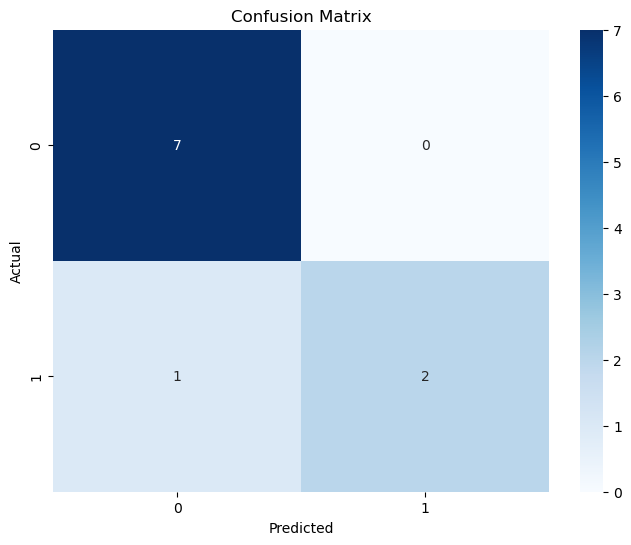

In [39]:
# Visualizing confusion matrix using Seborn
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

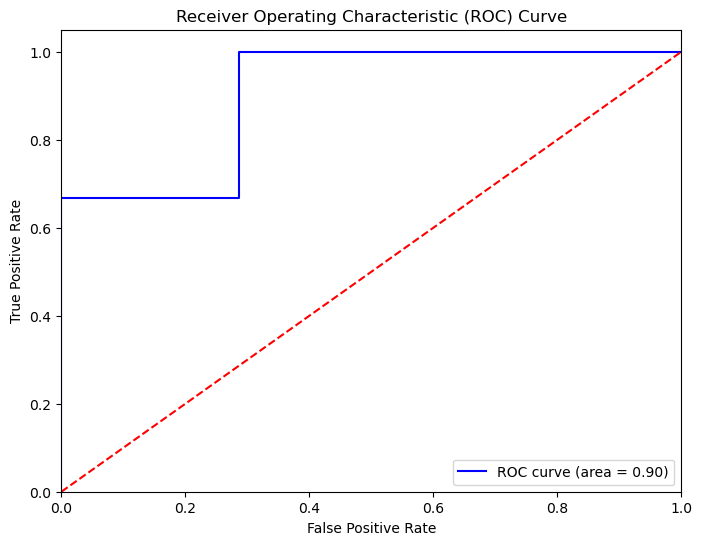

In [42]:
# visualizing the ROC curve
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()